In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load dataset
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

# Lihat ukuran data
print("Shape:", df.shape)
print("\nKolom:")
print(df.columns.tolist())

Shape: (9974, 53)

Kolom:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status'

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9974 entries, 0 to 9973
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           9974 non-null   object 
 1   Days for shipping (real)       9974 non-null   int64  
 2   Days for shipment (scheduled)  9974 non-null   int64  
 3   Benefit per order              9974 non-null   float64
 4   Sales per customer             9974 non-null   float64
 5   Delivery Status                9974 non-null   object 
 6   Late_delivery_risk             9974 non-null   int64  
 7   Category Id                    9974 non-null   int64  
 8   Category Name                  9974 non-null   object 
 9   Customer City                  9974 non-null   object 
 10  Customer Country               9974 non-null   object 
 11  Customer Email                 9974 non-null   object 
 12  Customer Fname                 9974 non-null   o

In [5]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,9974.000000,9974.000000,9974.000000,9974.000000,9974.000000,9974.000000,9974.000000,9974.000000,9974.000000,9974.000000,...,9973.000000,9973.000000,9973.000000,9973.000000,1283.000000,9973.000000,9973.000000,0.0,9973.000000,9973.0
mean,3.710748,3.179366,21.140662,178.226459,0.538199,26.387808,7142.233808,31555.092942,4.550331,28.298398,...,2.439487,198.803359,178.210642,21.142411,55523.643024,558.506267,26.389552,NaN,120.176505,0.0
std,1.515802,1.195856,106.396499,117.992430,0.498564,17.043606,4618.370337,37128.946926,1.642348,9.887148,...,1.555457,131.235657,117.987771,106.401690,31649.294294,342.166048,17.043571,NaN,129.066869,0.0
min,0.000000,0.000000,-3366.000000,8.470000,0.000000,2.000000,1.000000,603.000000,2.000000,17.982491,...,1.000000,11.290000,8.470000,-3366.000000,1453.000000,24.000000,2.000000,NaN,11.290000,0.0
25%,2.000000,2.000000,6.505000,98.000000,0.000000,17.000000,3441.750000,725.000000,4.000000,18.254036,...,1.000000,119.970001,98.000000,6.520000,27604.000000,365.000000,17.000000,NaN,50.000000,0.0
50%,4.000000,4.000000,29.570000,148.759995,1.000000,24.000000,6784.000000,10040.000000,4.000000,29.720747,...,2.000000,159.960007,148.759995,29.570000,60540.000000,403.000000,24.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,63.067500,251.960007,1.000000,36.000000,10113.250000,72308.750000,5.000000,38.037601,...,4.000000,299.950012,251.960007,63.070000,90004.000000,642.000000,36.000000,NaN,129.990005,0.0
max,6.000000,4.000000,614.250000,1470.000000,1.000000,76.000000,20755.000000,98632.000000,12.000000,48.781933,...,5.000000,1500.000000,1470.000000,614.250000,99301.000000,1363.000000,76.000000,NaN,1500.000000,0.0


**Data Cleaning**

In [7]:
# Cek missing values
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing Values:
Longitude                        1
Market                           1
Order City                       1
Order Country                    1
Order Customer Id                1
order date (DateOrders)          1
Order Id                         1
Order Item Cardprod Id           1
Order Item Discount              1
Order Item Discount Rate         1
Order Item Id                    1
Order Item Product Price         1
Order Item Profit Ratio          1
Order Item Quantity              1
Sales                            1
Order Item Total                 1
Order Profit Per Order           1
Order Region                     1
Order State                      1
Order Status                     1
Order Zipcode                 8691
Product Card Id                  1
Product Category Id              1
Product Description           9974
Product Image                    1
Product Name                     1
Product Price                    1
Product Status                   1
shi

In [8]:
# Pilih kolom yang relevan
cols_needed = [
    'Order Id',
    'order date (DateOrders)',
    'shipping date (DateOrders)',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Delivery Status',
    'Late_delivery_risk',
    'Shipping Mode',
    'Category Name',
    'Department Name',
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Benefit per order',
    'Order Item Discount Rate',
    'Customer Segment',
    'Market',
    'Order Region',
    'Order Country',
    'Order Status'
]

df = df[cols_needed].copy()

In [9]:
# Rename kolom agar lebih rapi
df.columns = [
    'order_id',
    'order_date',
    'shipping_date',
    'days_real',
    'days_scheduled',
    'delivery_status',
    'late_risk',
    'shipping_mode',
    'category',
    'department',
    'quantity',
    'sales',
    'order_total',
    'profit',
    'benefit',
    'discount_rate',
    'customer_segment',
    'market',
    'region',
    'country',
    'order_status'
]

In [10]:
# Convert tanggal
df['order_date'] = pd.to_datetime(df['order_date'])
df['shipping_date'] = pd.to_datetime(df['shipping_date'])

# Feature Engineering
# 1. Delay days (selisih aktual vs scheduled)
df['delay_days'] = df['days_real'] - df['days_scheduled']

# 2. Is late flag dari Delivery Status
df['is_late'] = df['delivery_status'] == 'Late delivery'

# 3. Ekstrak waktu
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['year_month'] = df['order_date'].dt.to_period('M')

# 4. Profit margin
df['profit_margin'] = (df['profit'] / df['order_total'].replace(0, np.nan) * 100).round(2)

print("Data setelah cleaning:")
print(df.shape)
print(df.dtypes)

Data setelah cleaning:
(9974, 27)
order_id                   float64
order_date          datetime64[ns]
shipping_date       datetime64[ns]
days_real                    int64
days_scheduled               int64
delivery_status             object
late_risk                    int64
shipping_mode               object
category                    object
department                  object
quantity                   float64
sales                      float64
order_total                float64
profit                     float64
benefit                    float64
discount_rate              float64
customer_segment            object
market                      object
region                      object
country                     object
order_status                object
delay_days                   int64
is_late                       bool
order_year                 float64
order_month                float64
year_month               period[M]
profit_margin              float64
dtype: object


In [11]:
# Validasi data
print("\nDelivery Status unique values:")
print(df['delivery_status'].value_counts())

print("\nShipping Mode unique values:")
print(df['shipping_mode'].value_counts())

print("\nCustomer Segment unique values:")
print(df['customer_segment'].value_counts())


Delivery Status unique values:
delivery_status
Late delivery        5368
Advance shipping     2523
Shipping on time     1739
Shipping canceled     344
Name: count, dtype: int64

Shipping Mode unique values:
shipping_mode
Standard Class    6601
Second Class      2074
First Class       1155
Same Day           143
Name: count, dtype: int64

Customer Segment unique values:
customer_segment
Consumer       4745
Corporate      3686
Home Office    1543
Name: count, dtype: int64


**Delivery Performance Analysis**

In [12]:
# ============================================
# ANALISIS 1: Overall Delivery Status
# ============================================

delivery_counts = df['delivery_status'].value_counts()
delivery_pct = delivery_counts / len(df) * 100

print("=" * 45)
print("    DELIVERY STATUS OVERVIEW")
print("=" * 45)
for status, count in delivery_counts.items():
    pct = delivery_pct[status]
    print(f"  {status:<25} : {count:>5} ({pct:.1f}%)")
print("=" * 45)

    DELIVERY STATUS OVERVIEW
  Late delivery             :  5368 (53.8%)
  Advance shipping          :  2523 (25.3%)
  Shipping on time          :  1739 (17.4%)
  Shipping canceled         :   344 (3.4%)


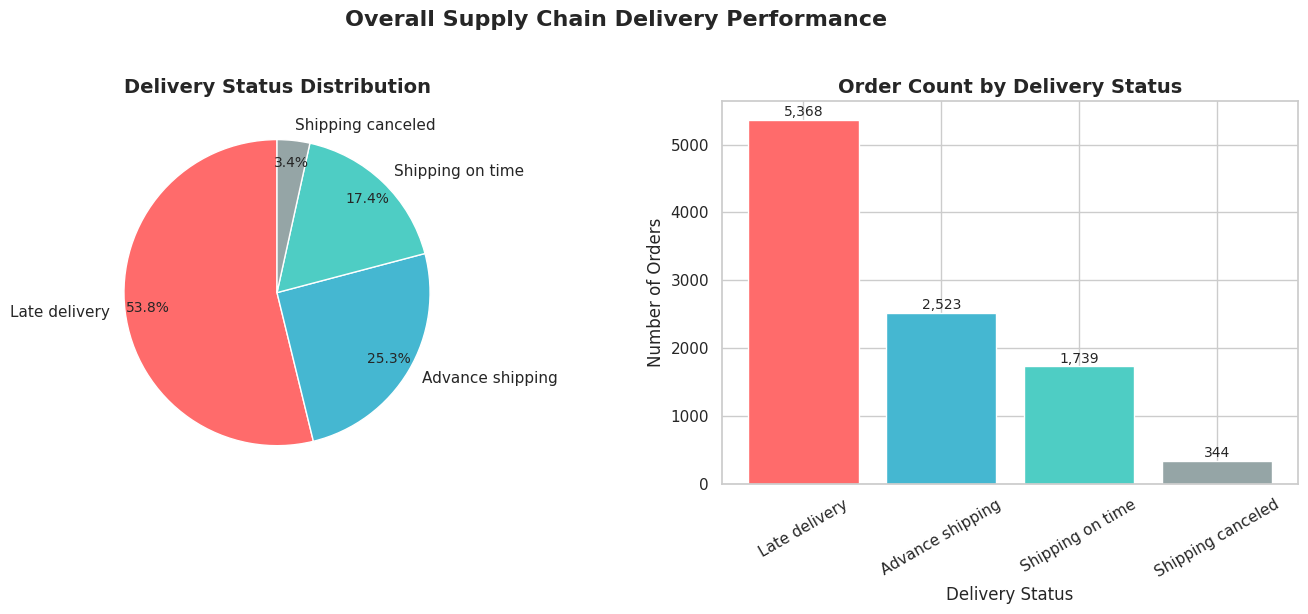

In [13]:
# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Warna: merah untuk late, hijau untuk on time, biru untuk advance
color_map = {
    'Late delivery': '#FF6B6B',
    'Shipping on time': '#4ECDC4',
    'Advance shipping': '#45B7D1',
    'Shipping canceled': '#95A5A6'
}
colors = [color_map.get(s, '#95A5A6') for s in delivery_counts.index]

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    delivery_counts.values,
    labels=delivery_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontsize(10)
axes[0].set_title('Delivery Status Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(delivery_counts.index, delivery_counts.values, color=colors)
for bar, val in zip(bars, delivery_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{val:,}',
        ha='center', fontsize=10
    )
axes[1].set_title('Order Count by Delivery Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Delivery Status')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Overall Supply Chain Delivery Performance',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_delivery_overview.png', dpi=150, bbox_inches='tight')
plt.show()

**Category & Department Analysis**

In [14]:
# ============================================
# ANALISIS 2: Late Rate per Category
# ============================================

cat_perf = df.groupby('category').agg(
    total=('order_id', 'count'),
    late=('is_late', 'sum'),
    avg_delay=('delay_days', 'mean'),
    avg_profit=('profit', 'mean')
).reset_index()

cat_perf['late_rate'] = (cat_perf['late'] / cat_perf['total'] * 100).round(1)
cat_perf = cat_perf.sort_values('late_rate', ascending=False)

print("Category Performance (sorted by late rate):")
print(cat_perf[['category', 'total', 'late_rate', 'avg_delay', 'avg_profit']].to_string(index=False))

Category Performance (sorted by late rate):
            category  total  late_rate  avg_delay  avg_profit
   Strength Training      2      100.0   1.500000   54.349999
               Baby      10       80.0   0.900000   10.576000
                CDs      14       78.6   1.285714   -0.475714
            Cameras      48       77.1   0.916667   56.348332
          Basketball      4       75.0   1.250000  153.824997
Consumer Electronics     25       72.0   1.160000   47.126800
        Pet Supplies     24       70.8   1.125000    1.951667
 Children's Clothing     34       70.6   0.705882   42.539117
              Crafts     35       68.6   0.914286   96.898857
           Computers     21       66.7   1.238095  150.046668
              Soccer     14       64.3   0.785714   77.387142
             Fishing    377       63.7   0.840849   40.490743
      Men's Footwear   1328       63.6   0.753765   13.024511
              Books      29       62.1   0.620690   -0.743104
   Health and Beauty     1

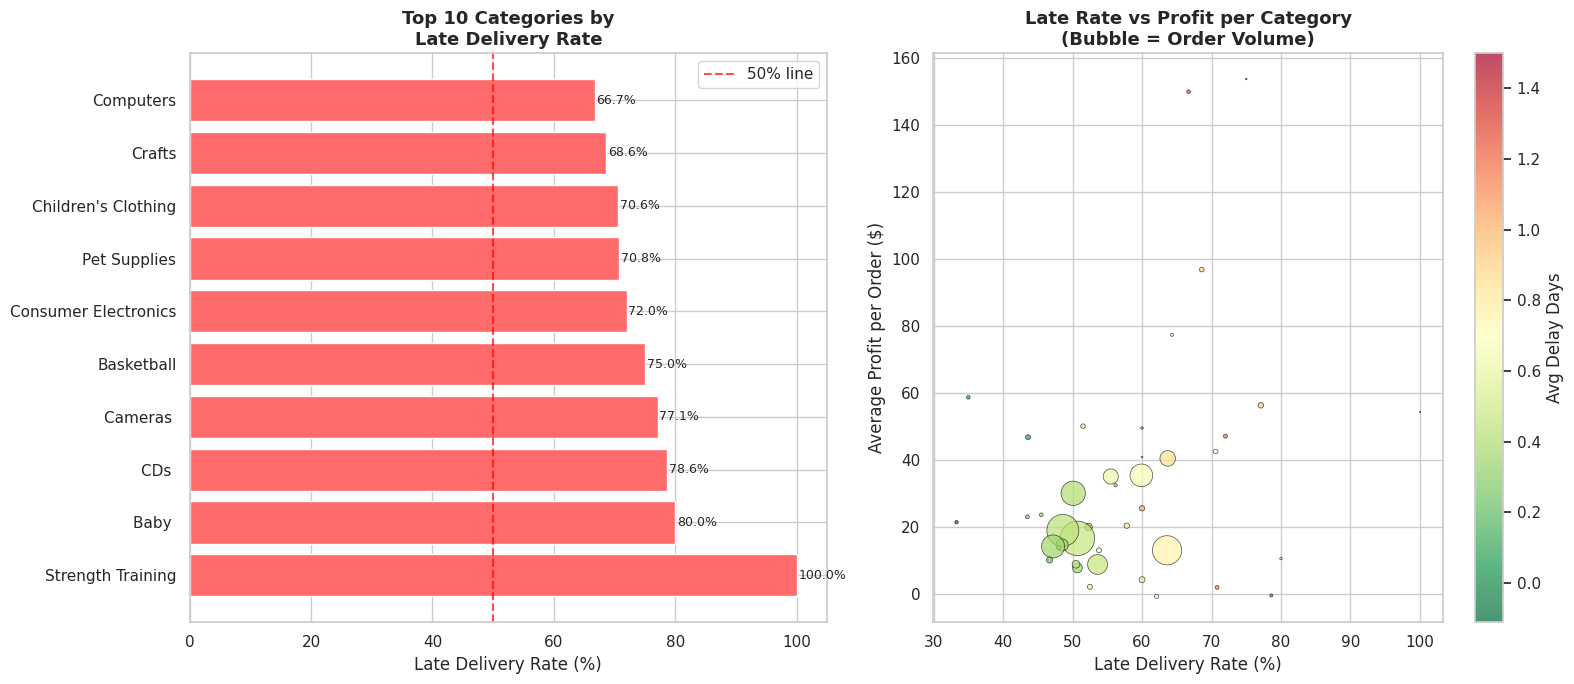

In [15]:
# Visualisasi Category
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Late rate per category (horizontal bar)
top10 = cat_perf.head(10)
bar_colors = ['#FF6B6B' if x >= 55 else '#FFA07A' if x >= 50 else '#4ECDC4'
              for x in top10['late_rate']]

bars = axes[0].barh(top10['category'], top10['late_rate'], color=bar_colors)
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% line')

for bar, val in zip(bars, top10['late_rate']):
    axes[0].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{val}%', va='center', fontsize=9
    )

axes[0].set_xlabel('Late Delivery Rate (%)')
axes[0].set_title('Top 10 Categories by\nLate Delivery Rate',
                  fontsize=13, fontweight='bold')
axes[0].legend()

# Scatter: Late Rate vs Avg Profit
scatter = axes[1].scatter(
    cat_perf['late_rate'],
    cat_perf['avg_profit'],
    s=cat_perf['total'] / 3,
    c=cat_perf['avg_delay'],
    cmap='RdYlGn_r',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(scatter, ax=axes[1], label='Avg Delay Days')
axes[1].set_xlabel('Late Delivery Rate (%)')
axes[1].set_ylabel('Average Profit per Order ($)')
axes[1].set_title('Late Rate vs Profit per Category\n(Bubble = Order Volume)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('02_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Shipping Mode Analysis**

In [16]:
# ============================================
# ANALISIS 3: Shipping Mode Performance
# ============================================

ship_perf = df.groupby('shipping_mode').agg(
    total=('order_id', 'count'),
    late=('is_late', 'sum'),
    avg_days_real=('days_real', 'mean'),
    avg_days_sched=('days_scheduled', 'mean'),
    avg_delay=('delay_days', 'mean'),
    avg_profit=('profit', 'mean')
).reset_index()

ship_perf['late_rate'] = (ship_perf['late'] / ship_perf['total'] * 100).round(1)
ship_perf['avg_days_real'] = ship_perf['avg_days_real'].round(1)
ship_perf['avg_delay'] = ship_perf['avg_delay'].round(2)

print("\nShipping Mode Performance Summary:")
print(ship_perf[['shipping_mode', 'total', 'late_rate',
                 'avg_days_real', 'avg_days_sched', 'avg_delay']].to_string(index=False))


Shipping Mode Performance Summary:
 shipping_mode  total  late_rate  avg_days_real  avg_days_sched  avg_delay
   First Class   1155       99.7            2.0             1.0       1.00
      Same Day    143       56.6            0.6             0.0       0.59
  Second Class   2074       79.9            4.0             2.0       2.01
Standard Class   6601       37.5            4.0             4.0      -0.02


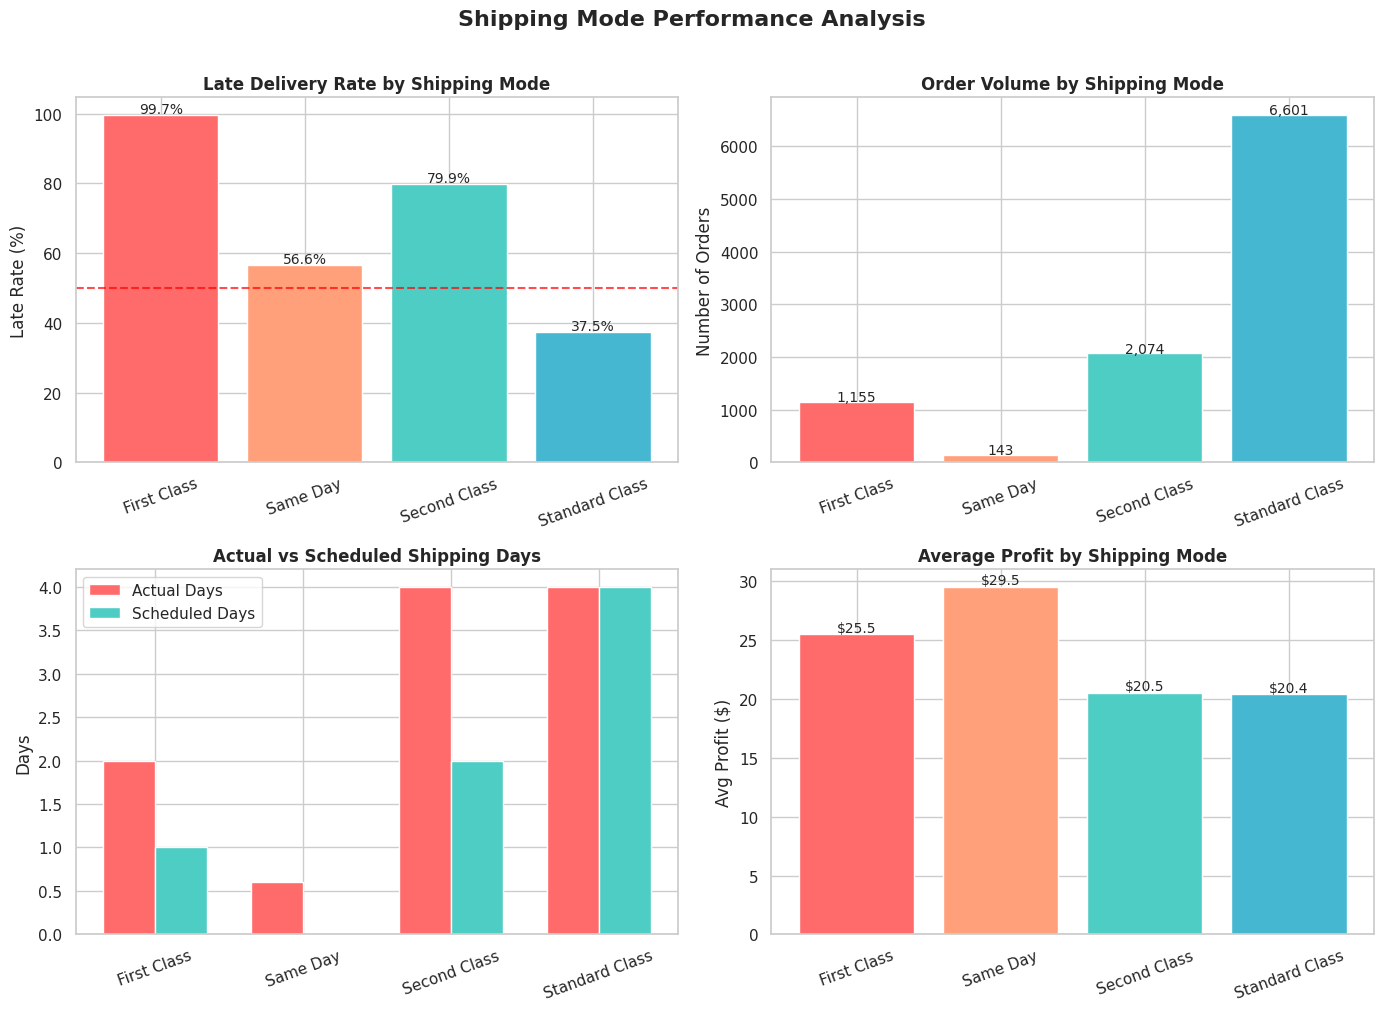

In [17]:
# Visualisasi Shipping Mode
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ship_colors = ['#FF6B6B', '#FFA07A', '#4ECDC4', '#45B7D1']

# 1. Late rate per mode
axes[0,0].bar(ship_perf['shipping_mode'], ship_perf['late_rate'],
              color=ship_colors)
axes[0,0].axhline(y=50, color='red', linestyle='--', alpha=0.7)
for i, (mode, rate) in enumerate(zip(ship_perf['shipping_mode'], ship_perf['late_rate'])):
    axes[0,0].text(i, rate + 0.5, f'{rate}%', ha='center', fontsize=10)
axes[0,0].set_title('Late Delivery Rate by Shipping Mode', fontweight='bold')
axes[0,0].set_ylabel('Late Rate (%)')
axes[0,0].tick_params(axis='x', rotation=20)

# 2. Volume per mode
axes[0,1].bar(ship_perf['shipping_mode'], ship_perf['total'],
              color=ship_colors)
for i, (mode, total) in enumerate(zip(ship_perf['shipping_mode'], ship_perf['total'])):
    axes[0,1].text(i, total + 10, f'{total:,}', ha='center', fontsize=10)
axes[0,1].set_title('Order Volume by Shipping Mode', fontweight='bold')
axes[0,1].set_ylabel('Number of Orders')
axes[0,1].tick_params(axis='x', rotation=20)

# 3. Avg real vs scheduled days
x = range(len(ship_perf))
width = 0.35
axes[1,0].bar([i - width/2 for i in x], ship_perf['avg_days_real'],
              width, label='Actual Days', color='#FF6B6B')
axes[1,0].bar([i + width/2 for i in x], ship_perf['avg_days_sched'],
              width, label='Scheduled Days', color='#4ECDC4')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(ship_perf['shipping_mode'], rotation=20)
axes[1,0].set_title('Actual vs Scheduled Shipping Days', fontweight='bold')
axes[1,0].set_ylabel('Days')
axes[1,0].legend()

# 4. Avg profit per mode
axes[1,1].bar(ship_perf['shipping_mode'], ship_perf['avg_profit'],
              color=ship_colors)
for i, (mode, profit) in enumerate(zip(ship_perf['shipping_mode'], ship_perf['avg_profit'])):
    axes[1,1].text(i, profit + 0.2, f'${profit:.1f}', ha='center', fontsize=10)
axes[1,1].set_title('Average Profit by Shipping Mode', fontweight='bold')
axes[1,1].set_ylabel('Avg Profit ($)')
axes[1,1].tick_params(axis='x', rotation=20)

plt.suptitle('Shipping Mode Performance Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_shipping_mode.png', dpi=150, bbox_inches='tight')
plt.show()

**Market & Region Analysis**

In [18]:
# ============================================
# ANALISIS 4: Market & Region Performance
# ============================================

market_perf = df.groupby('market').agg(
    total=('order_id', 'count'),
    late=('is_late', 'sum'),
    avg_delay=('delay_days', 'mean'),
    total_sales=('sales', 'sum'),
    avg_profit=('profit', 'mean')
).reset_index()

market_perf['late_rate'] = (market_perf['late'] / market_perf['total'] * 100).round(1)
market_perf['total_sales'] = market_perf['total_sales'].round(0)
market_perf = market_perf.sort_values('late_rate', ascending=False)

print("Market Performance:")
print(market_perf[['market', 'total', 'late_rate', 'avg_delay', 'total_sales']].to_string(index=False))

Market Performance:
      market  total  late_rate  avg_delay  total_sales
      Europe   2673       60.5   0.682379     563427.0
      Africa    499       56.1   0.525050      84775.0
       LATAM   2511       51.5   0.507766     480642.0
        USCA   1336       50.9   0.469311     225587.0
Pacific Asia   2954       50.6   0.443466     628235.0


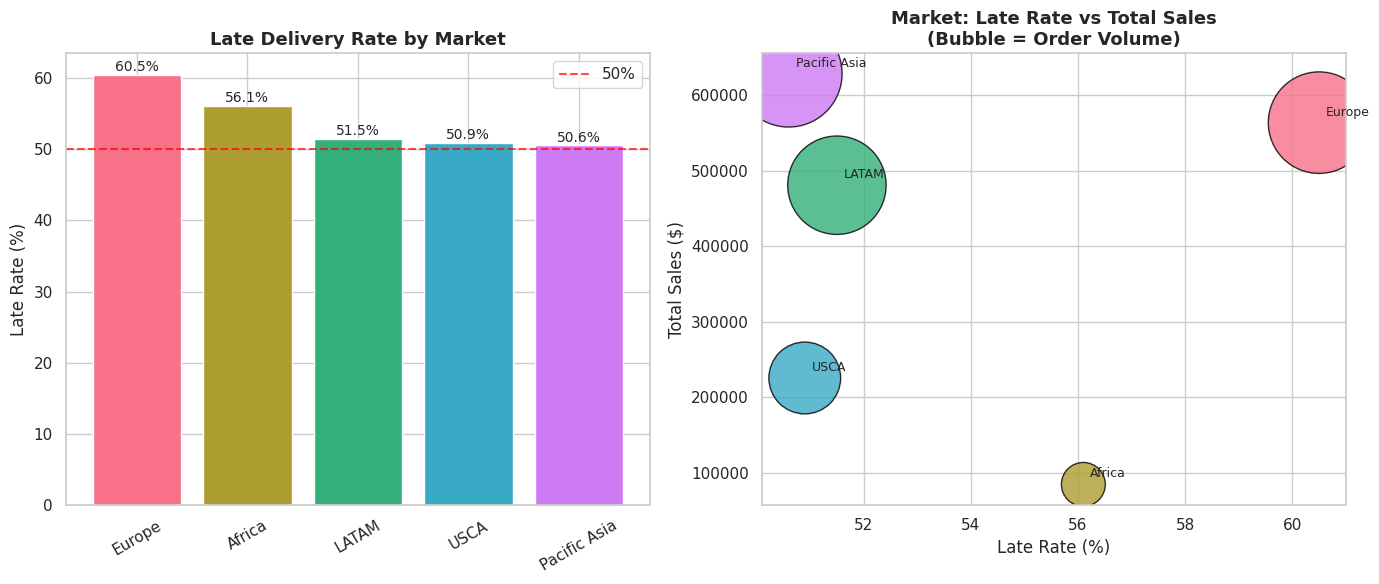

In [19]:
# Visualisasi Market
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

market_colors = sns.color_palette("husl", len(market_perf))

# Late rate per market
bars = axes[0].bar(market_perf['market'], market_perf['late_rate'],
                   color=market_colors)
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50%')
for bar, val in zip(bars, market_perf['late_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontsize=10)
axes[0].set_title('Late Delivery Rate by Market', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Late Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Sales vs Late Rate (bubble = order volume)
scatter = axes[1].scatter(
    market_perf['late_rate'],
    market_perf['total_sales'],
    s=market_perf['total'] * 2,
    c=market_colors,
    alpha=0.8,
    edgecolors='black'
)
for _, row in market_perf.iterrows():
    axes[1].annotate(row['market'],
                     (row['late_rate'], row['total_sales']),
                     textcoords="offset points",
                     xytext=(5, 5), fontsize=9)
axes[1].set_xlabel('Late Rate (%)')
axes[1].set_ylabel('Total Sales ($)')
axes[1].set_title('Market: Late Rate vs Total Sales\n(Bubble = Order Volume)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('04_market_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Customer Segment Analysis**

In [20]:
# ============================================
# ANALISIS 5: Customer Segment
# ============================================

segment_perf = df.groupby('customer_segment').agg(
    total=('order_id', 'count'),
    late=('is_late', 'sum'),
    avg_profit=('profit', 'mean'),
    total_sales=('sales', 'sum'),
    avg_discount=('discount_rate', 'mean')
).reset_index()

segment_perf['late_rate'] = (segment_perf['late'] / segment_perf['total'] * 100).round(1)
segment_perf['avg_discount'] = (segment_perf['avg_discount'] * 100).round(1)
segment_perf = segment_perf.sort_values('late_rate', ascending=False)

print("Customer Segment Performance:")
print(segment_perf.to_string(index=False))

Customer Segment Performance:
customer_segment  total  late  avg_profit  total_sales  avg_discount  late_rate
        Consumer   4745  2890   23.308156 1.037151e+06          10.4       60.9
     Home Office   1543   756   17.925107 2.869616e+05          10.2       49.0
       Corporate   3685  1722   19.700847 6.585536e+05          10.3       46.7


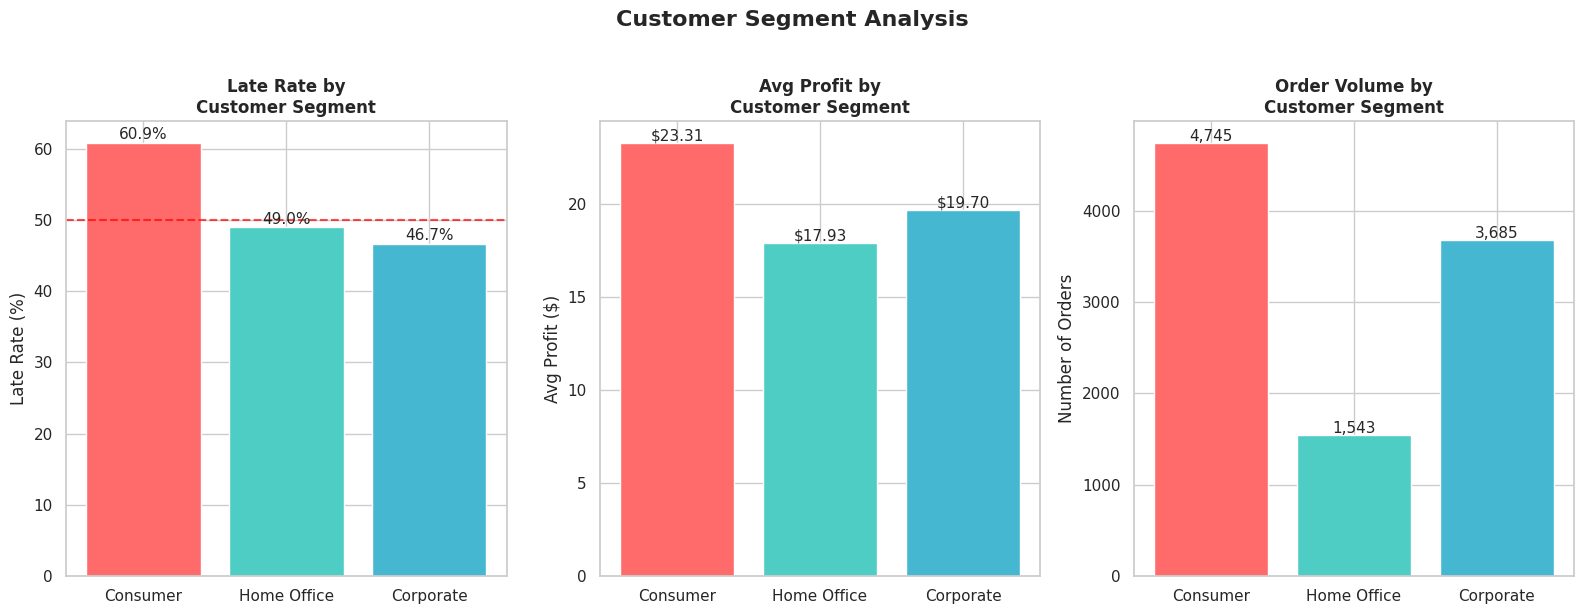

In [21]:
# Visualisasi Customer Segment
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

seg_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Late rate
axes[0].bar(segment_perf['customer_segment'], segment_perf['late_rate'],
            color=seg_colors)
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.7)
for i, (seg, rate) in enumerate(zip(segment_perf['customer_segment'],
                                     segment_perf['late_rate'])):
    axes[0].text(i, rate + 0.5, f'{rate}%', ha='center', fontsize=11)
axes[0].set_title('Late Rate by\nCustomer Segment', fontweight='bold')
axes[0].set_ylabel('Late Rate (%)')

# Avg profit per segment
axes[1].bar(segment_perf['customer_segment'], segment_perf['avg_profit'],
            color=seg_colors)
for i, (seg, profit) in enumerate(zip(segment_perf['customer_segment'],
                                       segment_perf['avg_profit'])):
    axes[1].text(i, profit + 0.1, f'${profit:.2f}', ha='center', fontsize=11)
axes[1].set_title('Avg Profit by\nCustomer Segment', fontweight='bold')
axes[1].set_ylabel('Avg Profit ($)')

# Order volume
axes[2].bar(segment_perf['customer_segment'], segment_perf['total'],
            color=seg_colors)
for i, (seg, total) in enumerate(zip(segment_perf['customer_segment'],
                                      segment_perf['total'])):
    axes[2].text(i, total + 20, f'{total:,}', ha='center', fontsize=11)
axes[2].set_title('Order Volume by\nCustomer Segment', fontweight='bold')
axes[2].set_ylabel('Number of Orders')

plt.suptitle('Customer Segment Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_customer_segment.png', dpi=150, bbox_inches='tight')
plt.show()

**Financial Impact Analysis**

In [22]:
# ============================================
# ANALISIS 6: Financial Impact of Late Delivery
# ============================================

# Profit comparison: late vs on-time
financial_impact = df.groupby('is_late').agg(
    count=('order_id', 'count'),
    avg_profit=('profit', 'mean'),
    avg_sales=('sales', 'mean'),
    avg_benefit=('benefit', 'mean'),
    avg_discount=('discount_rate', 'mean')
).reset_index()

financial_impact['label'] = financial_impact['is_late'].map(
    {True: 'Late Delivery', False: 'On Time / Advance'}
)

print("\nFinancial Impact: Late vs On-Time:")
print(financial_impact[['label', 'count', 'avg_profit', 'avg_sales', 'avg_benefit']].to_string(index=False))

# Estimated financial loss
late_count = df[df['is_late']].shape[0]
ontime_count = df[~df['is_late']].shape[0]
avg_profit_late = df[df['is_late']]['profit'].mean()
avg_profit_ontime = df[~df['is_late']]['profit'].mean()
profit_gap = avg_profit_ontime - avg_profit_late
total_loss = profit_gap * late_count

print(f"\n💰 Estimated Profit Gap per Order: ${profit_gap:.2f}")
print(f"📦 Total Late Orders: {late_count:,}")
print(f"⚠️  Estimated Total Profit Loss: ${total_loss:,.0f}")


Financial Impact: Late vs On-Time:
            label  count  avg_profit  avg_sales  avg_benefit
On Time / Advance   4606   21.456850 203.009456    21.456850
    Late Delivery   5367   20.872556 195.193654    20.869357

💰 Estimated Profit Gap per Order: $0.58
📦 Total Late Orders: 5,368
⚠️  Estimated Total Profit Loss: $3,136


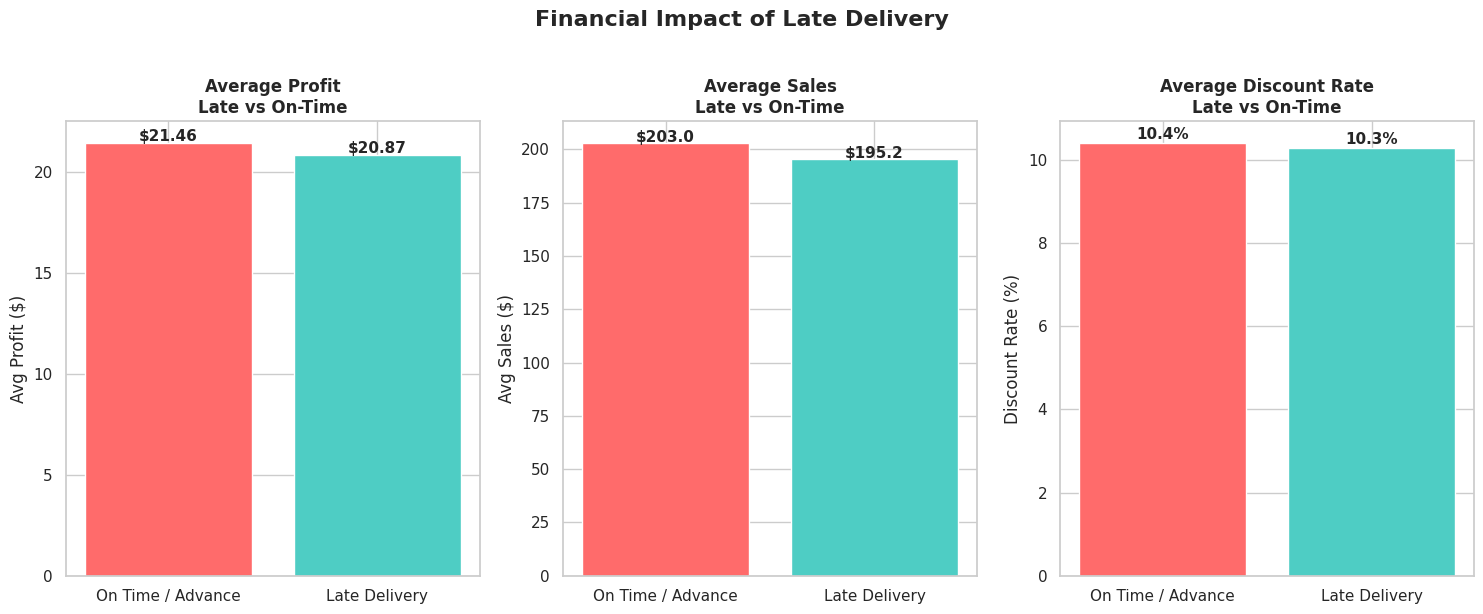

In [23]:
# Visualisasi Financial Impact
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

labels = financial_impact['label']
fin_colors = ['#FF6B6B', '#4ECDC4']

# Avg Profit
bars = axes[0].bar(labels, financial_impact['avg_profit'], color=fin_colors)
for bar, val in zip(bars, financial_impact['avg_profit']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'${val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Average Profit\nLate vs On-Time', fontweight='bold')
axes[0].set_ylabel('Avg Profit ($)')

# Avg Sales
bars = axes[1].bar(labels, financial_impact['avg_sales'], color=fin_colors)
for bar, val in zip(bars, financial_impact['avg_sales']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'${val:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Average Sales\nLate vs On-Time', fontweight='bold')
axes[1].set_ylabel('Avg Sales ($)')

# Avg Discount Rate
bars = axes[2].bar(labels, financial_impact['avg_discount'] * 100, color=fin_colors)
for bar, val in zip(bars, financial_impact['avg_discount'] * 100):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('Average Discount Rate\nLate vs On-Time', fontweight='bold')
axes[2].set_ylabel('Discount Rate (%)')

plt.suptitle('Financial Impact of Late Delivery',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_financial_impact.png', dpi=150, bbox_inches='tight')
plt.show()